# **深層生成モデル　第2回演習**


## 目次

1. [EMアルゴリズムによる混合ベルヌーイ分布の最適化](#scrollTo=ebCqfIix_L4X)
2. [EMアルゴリズムによる混合ガウス分布の最適化](#scrollTo=LNdUjqvL_L4a)
3. [参考文献](#scrollTo=EjuKOtgs_L4b)

In [1]:
# 必要なライブラリのインポート

import numpy as np
import matplotlib.pyplot as plt
import random
import copy
from keras.datasets import mnist
import seaborn as sns
import math
from scipy import stats
%matplotlib inline

In [2]:
# ヘルパー関数の定義

def get_label_idxs(labels: list, t_mnist: np.ndarray) -> np.ndarray:
    # 長さ60000のt_mnistについて，値が指定したラベルのうちのいずれかであるかのboolean arrayを取ってくる
    label_bool = np.any([t_mnist==label for label in labels], axis=0)
    # Trueである要素のインデックスを得る
    label_idxs = np.where(label_bool)[0]

    return label_idxs


def transforms(data_all: np.ndarray, flatten=True, binarize=True) -> np.ndarray:
    # 範囲を0~255から0~1にし，平坦化したあと，閾値0.5で0,1のバイナリにする
    data_all = data_all.astype(np.float64) / 255
    if flatten:
        data_all = data_all.reshape((data_all.shape[0], -1))
    if binarize:
        data_all = (data_all > 0.5).astype(np.uint8)

    return data_all

## 1.EMアルゴリズムによる混合ベルヌーイ分布の最適化

### 1.1 問題設定

本セクションでは，混合ベルヌーイ分布を用いてMNISTデータセットをモデリングしていきます．

以下では，ラベルが **0, 5, 7** の画像を合わせて1800枚用います．

観測データ集合は${\bf X}=\left\{{\bf x}_{i}\right\}_{i=1}^{N}$（ただし$N=1800$）．${\bf x}_i$は2値化された$i$枚目の画像（長さ784のベクター)です．

$K(=3)$個のラベルのうち，どのラベルの画像の値かを示す**潜在変数**を$\mathbf{z}=\left[z_1, z_2, z_3\right]^{T} \in\{0,1\}^3$とします．

- つまり$\mathbf{z}$は長さ$K$のone-hotベクトルで，${\sum_{k=1}^{K} z_{k}=1},\quad z_k \in \{0,1\}$

- $\mathbf{z} = [1, 0, 0]$ならラベルが0の画像を表す

$\mathbf{z}$が従う確率分布をカテゴリ分布とし，$z_k = 1$となる確率を$\pi_{k}$とします．

- $\sum_{k=1}^{K}\pi_{k}=1\qquad \pi_{k} \in[0,1]$

- カテゴリ分布の確率質量関数　$p_{\pi}(\mathbf{z})=\prod_{k=1}^{K} \pi_{k}^{z_{k}}$

###1.2 混合ベルヌーイ分布の復習

- 講義スライドの「潜在変数モデルと混合モデル」を参照してください．

ある潜在変数${\bf z}$を選んだ上で，確率変数$x$が従う確率分布は，

$$
p_{\mu}(x|{\bf z}) = \prod_{k=1}^K\left\{ \mu_k^x(1-\mu_k)^{1-x}\right\}^{z_k}
$$

- $z_k=1$となる$k$以外は$z_k=0$となるので，積に影響しない.

同時分布

$$
p_{\mu,\pi}(x,{\bf z}) = p_{\mu}(x|{\bf z})p_{\pi}({\bf z})
= \prod_{k=1}^K \left\{ \pi_k \mu_k^x (1-\mu_k)^{1-x} \right\} ^{z_k}
$$

周辺分布

$$
p_{\mu,\pi}(x) = \sum_z p_{\mu,\pi}(x,{\bf z})
= \sum_{k=1}^K p_{\mu,\pi}(x,z_k=1)
= \sum_{k=1}^K\pi_k\mu_k^x (1-\mu_k)^{1-x}
$$

$x$の周辺分布は，ベルヌーイ分布の線形和で表されることがわかりました．

この対数周辺尤度を最大化するようなパラメータ${\mu_k},{\pi_k}$を求めるために，EMアルゴリズムを用いて最適化を行っていきます．

In [3]:
NUM_SAMPLES = 1800

(x_mnist, t_mnist), _ = mnist.load_data()
print(f"x_mnist: {x_mnist.shape}, t_mnist: {t_mnist.shape}")

labels = [0, 5, 7]

label_idxs = get_label_idxs(labels, t_mnist)

data_all = x_mnist[label_idxs][:NUM_SAMPLES]
print(f"data_all: {data_all.shape}")

# 範囲を0~255から0~1にし，平坦化したあと，閾値0.5で0,1のバイナリにする
binary_data = transforms(data_all)
print(f"binary_data: {binary_data.shape}")

x_mnist: (60000, 28, 28), t_mnist: (60000,)
data_all: (1800, 28, 28)
binary_data: (1800, 784)


#### 多次元ベルヌーイ分布の対数尤度

1枚の画像について，多次元ベルヌーイ分布の確率質量関数は以下のようになります．$D$はピクセル数で，MNISTの場合は784です．($d$の添字が$\mu$にもついていることに注意してください.)

$$
p_\mu({\bf x}) = \prod_{d=1}^D\mu_d^{x_d}(1-\mu_d)^{1-{x_d}}
$$

対数をとると，

$$
{\rm log}\ p_\mu({\bf x}) = \sum_{d=1}^D \left\{x_d\ {\rm log\ }\mu_d + (1 - x_d)\ {\rm log\ }(1 - \mu_d)\right\}
$$

In [4]:
# float型では、(大体)1e-323未満の値は精度の問題で0.0となり、
# 対数を取ると -inf となるので下限を抑えておく
def np_log(x):
    return np.log(np.clip(a=x, a_min=1e-323, a_max=1e+10))

# ベルヌーイ分布の対数尤度を計算する関数
def log_bernoulli_density(x, mu): # x: ( 784, ), mu: ( 784, )
    log_p = x * np_log(mu) + (1 - x) * np_log(1 - mu) # ( 784, )
    log_p = np.sum(log_p)
    return log_p

### 1.3 全データに対する，混合ベルヌーイ分布の対数尤度

データ(画像)の数を$N$，混合数を$K$，各ベルヌーイ分布を$p_{\mu_k}(x)$とすると，全データ点に対する混合ベルヌーイ分布の対数尤度は，以下で表されます．

$$
{\rm log}\  p_\mu(X)= \sum_{i=1}^N{\rm log}\sum_{k=1}^K\pi_k p_{\mu_k}({\bf x}_i)
$$
<!--\quad\left( = \sum_{i=1}^N\log\sum_{k=1}^K\pi_k\mu_k^{x_i}(1-\mu_k)^{1-x_i} \right) -->

In [5]:
# 全てのデータ点を用いた，混合ベルヌーイ分布に対する対数尤度を計算する関数
def log_likelihood(binary_data, mu_list, pi_list):
    # binary_data: ( 1800, 784 ), mu_list: [ (784), (784), (784) ], pi_list: ( 3, )
    log_likely_all = 0
    for data in binary_data:
        likely = 0
        for k in range(len(pi_list)):
             likely += pi_list[k] * np.exp(log_bernoulli_density(data, mu_list[k]))
        log_likely_all += np_log(likely)

    return log_likely_all

### 1.4 負担率

負担率は，各データ点が与えられた上での潜在変数(カテゴリ)の事後確率を指します．

負担率を計算することは，各データ点がどのカテゴリからサンプリングされたかを推論することに相当します．

任意のピクセルに対し，$i$番目のデータ(画像)に対する，$k$番目の潜在変数を$z_{ik}$とすると，負担率は以下で表されます．

<!--$$
p_{\mu,\pi}(z_{ik}=1 | {\bf x}_i)
= \frac{p_{{\mu_k},{\pi_k}}({\bf x}_i,z_{ik}=1)}{\sum_{j=1}^K p_{{\mu_j},{\pi_j}}({\bf x}_i, z_{ik}=1)}
=\frac{\pi_k \mu_k^{{\bf x}_i}(1-\mu_k)^{1-{\bf x}_i}}{\sum_{j=1}^K\pi_j \mu_j^{{\bf x}_i}(1-\mu_j)^{1-{\bf x}_i}}
\equiv \gamma(z_{ik})
$$-->

$$
p_{\mu,\pi}(z_{ik}=1 | {\bf x}_i)
= \frac{p_{{\mu},{\pi}}({\bf x}_i,z_{ik}=1)}{\sum_{z} p_{\mu,\pi}({\bf x}_i, z_{ik}=1)}
=\frac{\pi_k\ p_{\mu_k}({\bf x}_i)}{\sum_{j=1}^K\pi_j\ p_{\mu_j}({\bf x}_i)}
\equiv \gamma(z_{ik})
$$

In [6]:
# 負担率を計算する関数
def responsibility(data_all, mu_list, pi_list):
    gamma_mat = np.zeros((data_all.shape[0], len(pi_list))) # ( 1800, 3 )
    for i in range(gamma_mat.shape[0]):
        for k in range(gamma_mat.shape[1]):
            gamma_mat[i][k] = log_bernoulli_density(data_all[i], mu_list[k])
        gamma_mat[i] -= np.max(gamma_mat[i])
        gamma_mat[i] = pi_list * np.exp(gamma_mat[i])
        gamma_mat[i] /= np.sum(gamma_mat[i])
    return gamma_mat

### 1.5 学習

EMアルゴリズムによる学習は，EステップとMステップを繰り返すことで最適化を行います．

1. Eステップ  
現在のパラメータのもとで，事後分布（負担率）を計算する.　$\gamma(z_{ik})=p_{\mu,\pi}(z_{ik}=1|{\bf x}_i)$

1. Mステップ  
負担率を用いて，新しいパラメータ$\mu_k$と$\pi_k$を推定して更新する.

混合ベルヌーイ分布ではMステップにおける更新式は以下となります(証明等はテキストを参照してください)

$$
\hat\pi_k = \frac{N_k}{N}\qquad
\hat\mu_k = \frac{1}{N_k} \sum_{i=1}^N\gamma(z_{ik})x_i
\qquad ただし，N_k = \sum_{i=1}^N\gamma(z_{ik})
$$

$\hat\pi_k$は全データの負担率の平均値，$\hat\mu_k$は負担率による重み付きサンプル平均に相当します．

EMアルゴリズムでは，各ステップごとの対数尤度が非減少であることが保証されており，増加幅が一定値以下となったら収束したとみなして，学習を終了します．

Iteration: 0, log_likelihood: -743.302944496077


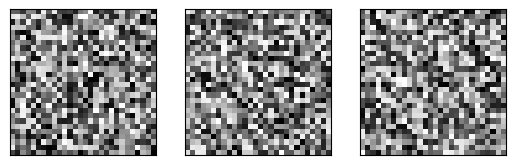

Iteration: 1, log_likelihood: -201.58918813588258
pi_list: [0.5908356897465831, 0.08842146969295378, 0.32074284056046326]


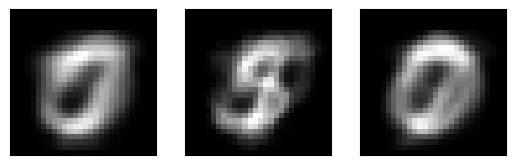

Iteration: 2, log_likelihood: -193.11528565087255
pi_list: [0.38305170722729537, 0.2912715442137656, 0.325676748558939]


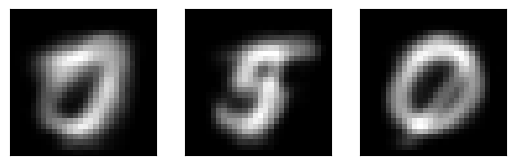

Iteration: 3, log_likelihood: -185.64943514864294
pi_list: [0.32965806708366274, 0.364946174748418, 0.30539575816791936]


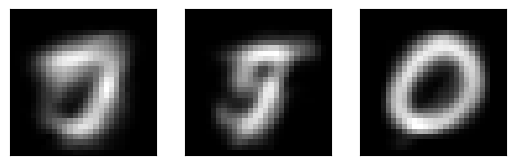

Iteration: 4, log_likelihood: -183.4802451911978
pi_list: [0.3080765537729252, 0.38749819819359016, 0.30442524803348464]


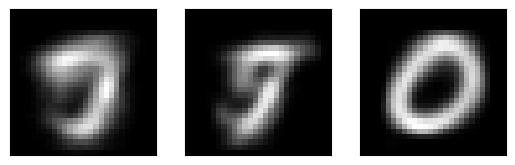

Iteration: 5, log_likelihood: -182.83748702630294
pi_list: [0.31441448869201905, 0.3778803292619187, 0.30770518204606223]


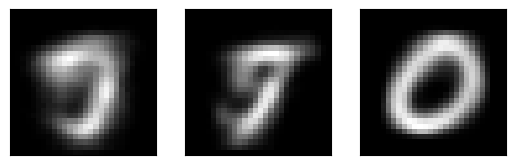

Iteration: 6, log_likelihood: -182.54730514833213
pi_list: [0.3257133553699041, 0.3656043845714285, 0.3086822600586674]


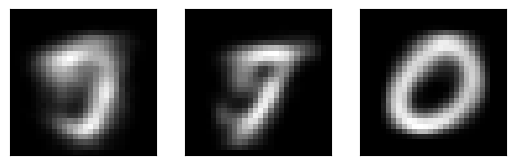

Iteration: 7, log_likelihood: -182.23624154924525
pi_list: [0.3372654354929961, 0.35476160722740085, 0.307972957279603]


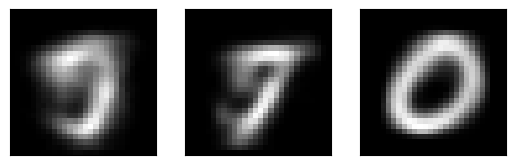

Iteration: 8, log_likelihood: -182.05906928463583
pi_list: [0.3454597533325094, 0.3472143696476, 0.3073258770198905]


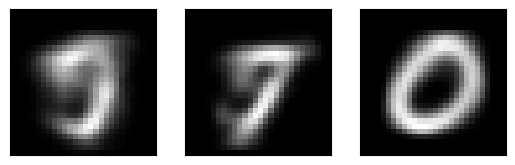

Iteration: 9, log_likelihood: -181.9963271524899
pi_list: [0.3507826466584926, 0.3423711413663675, 0.30684621197513995]


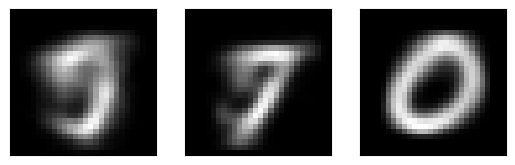

Iteration: 10, log_likelihood: -181.96039872993688
pi_list: [0.3536816201467065, 0.33938767495316396, 0.3069307049001296]


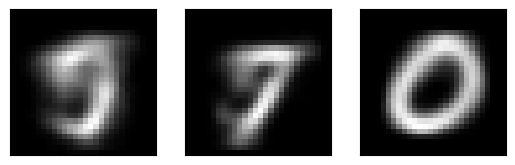

Iteration: 11, log_likelihood: -181.9500434043556
pi_list: [0.3554870078312014, 0.33769651714173277, 0.3068164750270658]


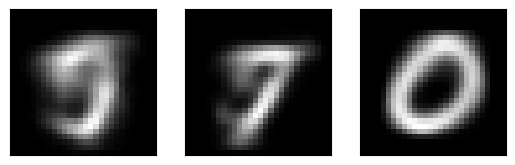

Iteration: 12, log_likelihood: -181.87147419017487
pi_list: [0.35534375557914055, 0.33778277147224534, 0.30687347294861417]


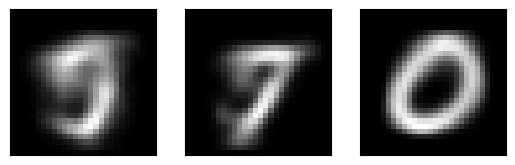

Iteration: 13, log_likelihood: -181.85393030516497
pi_list: [0.3531523817769658, 0.33983490985848624, 0.3070127083645479]


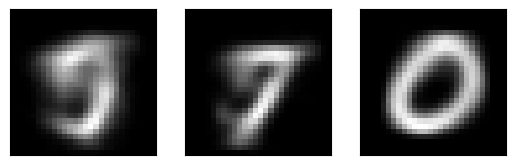

Iteration: 14, log_likelihood: -181.83173427849252
pi_list: [0.3519906895659462, 0.341144314236227, 0.3068649961978267]


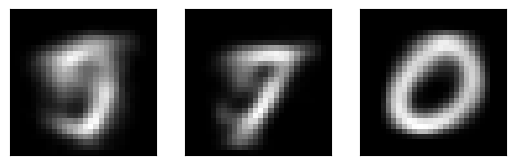

Iteration: 15, log_likelihood: -181.76071730175278
pi_list: [0.35031410845512934, 0.3431456509781147, 0.3065402405667559]


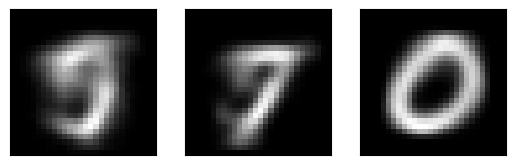

Iteration: 16, log_likelihood: -181.74485659547003
pi_list: [0.3485499285361054, 0.34557516958397066, 0.305874901879924]


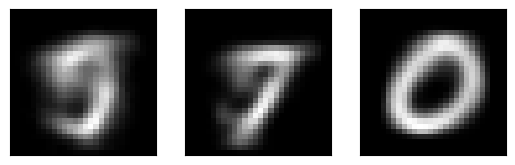

Iteration: 17, log_likelihood: -181.73617039730112
pi_list: [0.34928816165497056, 0.3460879607503608, 0.3046238775946688]


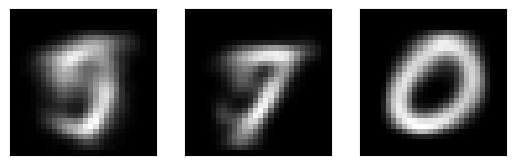

Iteration: 18, log_likelihood: -181.72257730461283
pi_list: [0.35028290721703165, 0.3469042742962825, 0.3028128184866858]


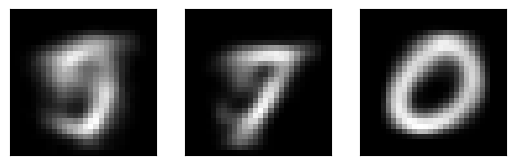

Iteration: 19, log_likelihood: -181.70440770981435
pi_list: [0.35045074033239243, 0.34923396027072484, 0.30031529939688273]


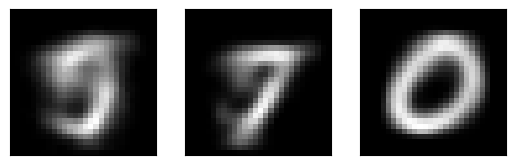

Iteration: 20, log_likelihood: -181.68809079140289
pi_list: [0.3506745382873589, 0.3520864057543449, 0.29723905595829603]


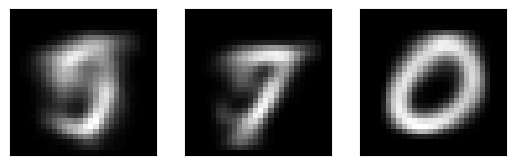

Iteration: 21, log_likelihood: -181.67744823016278
pi_list: [0.3509296831813175, 0.3545169647426204, 0.2945533520760621]


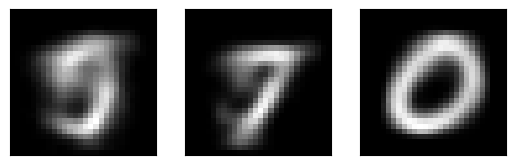

Iteration: 22, log_likelihood: -181.67086254570904
pi_list: [0.35074452710286, 0.35665890206737655, 0.2925965708297634]


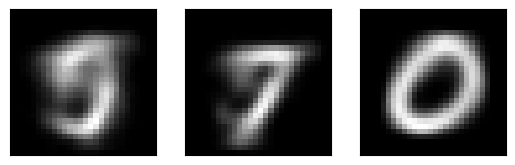

Iteration: 23, log_likelihood: -181.6670217419705
pi_list: [0.35075206969712935, 0.3581643627371266, 0.291083567565744]


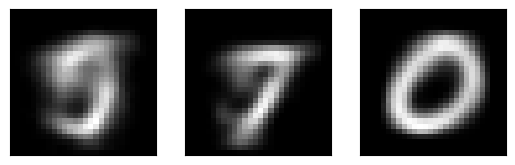

Iteration: 24, log_likelihood: -181.66392537385087
pi_list: [0.35080189188733757, 0.35930944739855536, 0.28988866071410707]


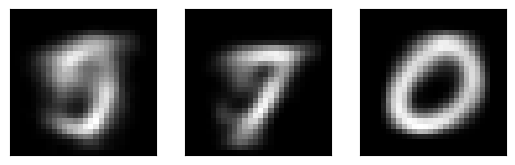

Iteration: 25, log_likelihood: -181.66054382060895
pi_list: [0.35073413302399103, 0.3604171087827811, 0.2888487581932278]


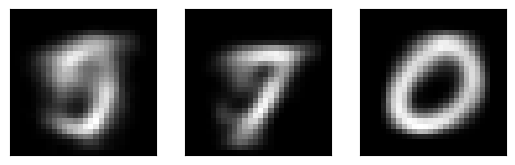

Iteration: 26, log_likelihood: -181.63146200846913
pi_list: [0.35078462214265976, 0.3615733340346007, 0.2876420438227396]


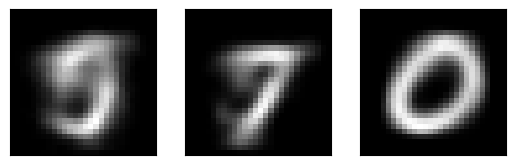

Iteration: 27, log_likelihood: -181.60392991082907
pi_list: [0.35024675108295644, 0.363556512066643, 0.28619673685040065]


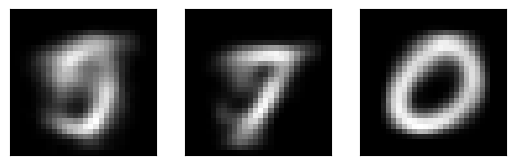

Iteration: 28, log_likelihood: -181.57542639332272
pi_list: [0.349033776681366, 0.3665589360784906, 0.28440728724014347]


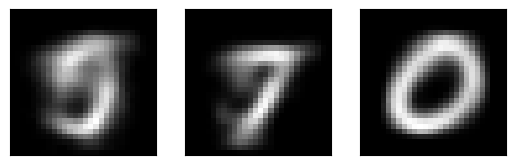

Iteration: 29, log_likelihood: -181.55332238201984
pi_list: [0.3480812921591268, 0.3696441888845294, 0.28227451895634387]


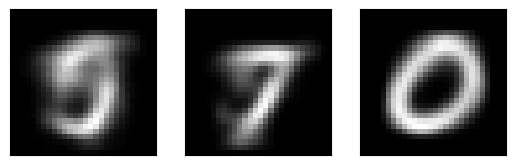

Iteration: 30, log_likelihood: -181.53186089971422
pi_list: [0.3484039019488304, 0.37151825757751006, 0.2800778404736595]


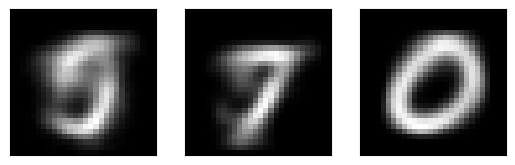

Iteration: 31, log_likelihood: -181.5109994261095
pi_list: [0.35005223774676664, 0.3723321451275805, 0.27761561712565297]


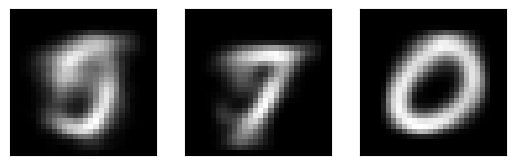

Iteration: 32, log_likelihood: -181.49946627091362
pi_list: [0.3514385792850825, 0.3736543419077961, 0.27490707880712145]


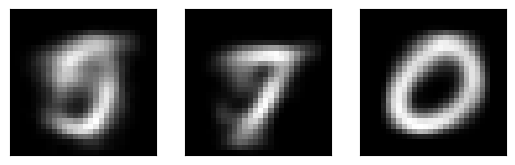

Iteration: 33, log_likelihood: -181.4898353134065
pi_list: [0.352465724168968, 0.3750714318033571, 0.27246284402767496]


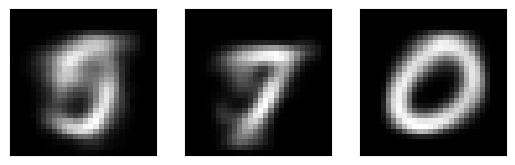

Iteration: 34, log_likelihood: -181.4785856410279
pi_list: [0.35295965381987854, 0.3769703069304889, 0.27007003924963247]


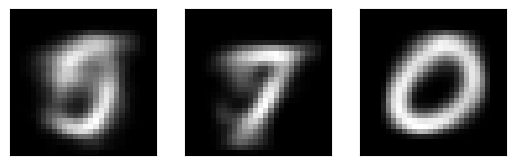

Iteration: 35, log_likelihood: -181.47076918729306
pi_list: [0.3539744882286643, 0.37828417369570233, 0.26774133807563333]


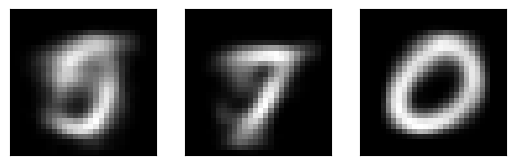

Iteration: 36, log_likelihood: -181.4675524304549
pi_list: [0.3548663865981864, 0.37880042180803986, 0.2663331915937737]


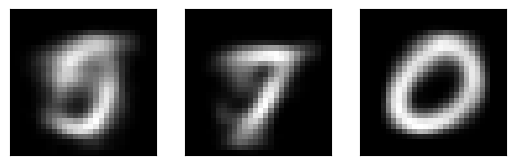

Iteration: 37, log_likelihood: -181.46373514283238
pi_list: [0.3562357649136274, 0.3786798987547453, 0.2650843363316273]


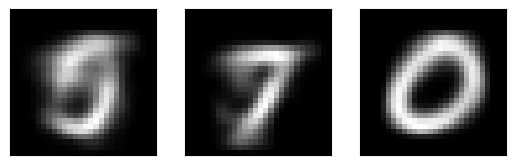

Iteration: 38, log_likelihood: -181.4599730576673
pi_list: [0.35792180654743394, 0.37798192542375203, 0.264096268028814]


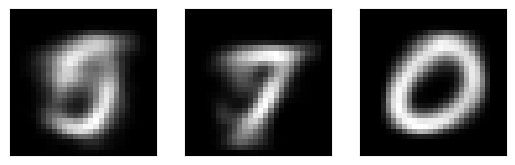

Iteration: 39, log_likelihood: -181.44731610884867
pi_list: [0.3593033476155286, 0.3773369242955733, 0.26335972808889796]


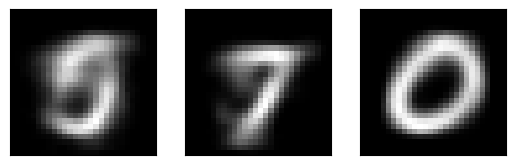

Iteration: 40, log_likelihood: -181.41531690849692
pi_list: [0.3594159111048709, 0.377771532125848, 0.26281255676928106]


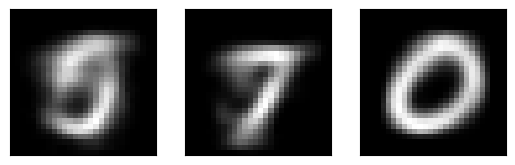

Iteration: 41, log_likelihood: -181.34531635003867
pi_list: [0.3578584539596359, 0.37980482055040427, 0.2623367254899599]


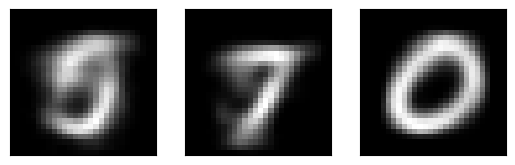

Iteration: 42, log_likelihood: -181.32047268377792
pi_list: [0.355135779650934, 0.38313716256076, 0.2617270577883061]


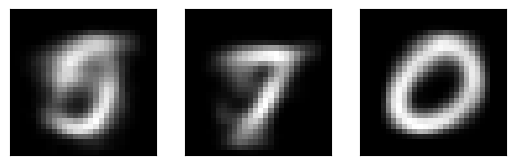

Iteration: 43, log_likelihood: -181.30589473740713
pi_list: [0.35341598909558625, 0.385604872207773, 0.2609791386966408]


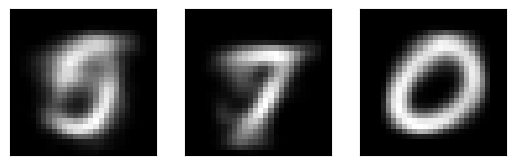

Iteration: 44, log_likelihood: -181.30160176955542
pi_list: [0.353231031482599, 0.38639597021205263, 0.26037299830534844]


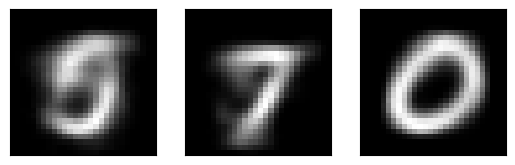

Iteration: 45, log_likelihood: -181.30111159911397
pi_list: [0.3536356128306697, 0.38633490120616015, 0.2600294859631702]


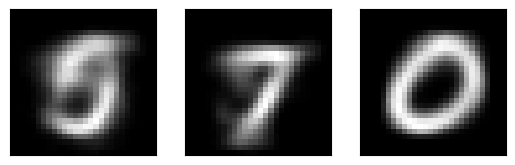

In [9]:
# 各ベルヌーイ分布のパラメータを適当な値で初期化
mu_list = [np.random.rand(binary_data.shape[1]) for _ in labels] # それぞれ ( 784, )

# 混合分布の重みを初期化
pi_list = [0.3, 0.3, 0.4]

n_iter = 0

# 現在のパラメータを用いて全データに対する対数尤度を計算
likely = log_likelihood(binary_data, mu_list, pi_list) / binary_data.shape[0]
print('Iteration: {0}, log_likelihood: {1}'.format(n_iter, likely))

fig = plt.figure()
for i in range(len(mu_list)):
    ax = fig.add_subplot(1, len(mu_list), i+1, xticks=[], yticks=[])
    ax.imshow(mu_list[i].reshape(28, 28), 'gray')
plt.show()

# 対数尤度の上がり幅がth以下になったら収束したと判定する
th = 0.001

# 学習
while True:
    n_iter += 1

    # Eステップ：現在のパラメータのもとでの事後分布（負担率）を計算
    gamma_mat = responsibility(binary_data, mu_list, pi_list) # ( 1800, 3 )
    n_k = np.sum(gamma_mat, axis=0) # ( 3, )

    # Mステップ：負担率を用いて，新しいパラメータを推定・更新
    # piの新しい推定量
    pi_list_next = (n_k / n_k.sum()).tolist()

    # gamma_mat: ( 1800, 3 ) binary_data: ( 1800, 784 ) n_k: ( 3, )
    mu_list_next = (binary_data.T@gamma_mat).T/n_k[:,None] # WRITE ME # ( 3, 784 )

    # muの新しい推定量．0次元目だけリストになる
    mu_list_next = list(mu_list_next) # [( 784, ), ( 784, ), ( 784, )]

    mu_list = copy.deepcopy(mu_list_next)
    pi_list = copy.deepcopy(pi_list_next)

    likely_before = likely.copy()

    likely = log_likelihood(binary_data, mu_list, pi_list) / binary_data.shape[0]# WRITE ME

    print('Iteration: {0}, log_likelihood: {1}'.format(n_iter, likely))

    delta = likely - likely_before

    print('pi_list: {}'.format(pi_list))
    # print("mu_list avg: {}".format([mu.mean() for mu in mu_list]))

    fig = plt.figure()
    for i in range(len(mu_list)):
        ax = fig.add_subplot(1, len(mu_list), i+1, xticks=[], yticks=[])
        ax.imshow(mu_list[i].reshape(28, 28), 'gray')
    plt.show()

    if delta < th and n_iter > 20:
        break

最後に，最適化したパラメータのベルヌーイ分布からサンプリングを行ってみます．

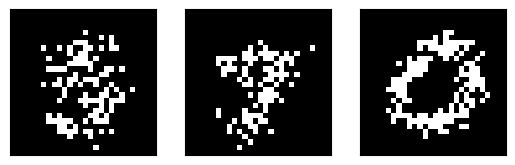

In [10]:
sampled_data = [np.random.binomial(n=1, p=mu) for mu in mu_list]

fig = plt.figure()
for i, sample in enumerate(sampled_data):
    ax = fig.add_subplot(1, len(mu_list), i+1, xticks=[], yticks=[])
    ax.imshow(sample.reshape(28, 28), 'gray')
plt.show()

## 2.EMアルゴリズムによる混合ガウス分布の最適化

### 2.1 問題設定

本セクションで用いるデータは，人工的に生成した2次元混合ガウス分布によるデータです．

先ほどの混合ベルヌーイ分布ではデータは784次元でしたが，今回2次元データを用いるのは，各学習ステップにおける分布の変化をわかりやすく可視化するためです．

In [11]:
#データ分布（混合ガウス分布）を定義してデータを生成する

mu0_data = np.array([0, -0.5])
sigma0_data = np.array([[1.0, 0], [0, 1.0]])

mu1_data = np.array([2.5, 2])
sigma1_data = np.array([[0.5, 0.3], [0.3, 0.7]])

mu2_data = np.array([-2, 1.5])
sigma2_data = np.array([[1.2, 0.2], [0.2, 0.4]])

mu_data_list = [mu0_data, mu1_data, mu2_data]
sigma_data_list = [sigma0_data, sigma1_data, sigma2_data]
sigma_data_inv_list = [np.linalg.inv(sigma) for sigma in sigma_data_list]
sigma_data_det_list = [np.linalg.det(sigma) for sigma in sigma_data_list]

pi_data_list = [0.45, 0.25, 0.3]


NUM_DATA = 3000

# 各データをどのガウス分布からサンプリングしてくるか．set {0, 1, 2}
categories = np.random.randint(len(pi_data_list), size=NUM_DATA) # ( 3000, )

data_all = []
for c in categories:
    data_all.append(
        np.random.multivariate_normal(
            mu_data_list[c], sigma_data_list[c]
        )
    )
data_all = np.stack(data_all) # [(2,), (2,).... (2,)] -> ( 3000, 2 )

print(f"data_all: {data_all.shape}")

data_all: (3000, 2)


#### 多次元ガウス分布の確率密度関数

D次元データに対するガウス分布の確率密度関数は以下で表されます．

$$
p_{\mu,\Sigma}({\bf x})
= \frac{1}{\sqrt{(2\pi)^D|\Sigma|}}{\rm exp}\left\{-\frac{1}{2}({\bf x} - {\bf \mu})^T \Sigma^{-1}({\bf x} - {\bf \mu})\right\}
\equiv N({\bf x}; {\bf \mu}, \Sigma)
$$

In [12]:
# 一つのデータ点に対してガウス分布の尤度を計算する関数
def gaussian_density(x, mu, sigma_inv, sigma_det):
    # x: ( 2, ) mu: ( 2, ) sigma_inv: ( 2, 2 ) sigma_det: ()
    diff = x - mu
    z = np.exp(-np.dot(diff, np.dot(sigma_inv, diff.T)) / 2)
    p = z / np.sqrt((np.power(2*np.pi, sigma_inv.shape[0]) * sigma_det))
    return p

混合ガウス分布の周辺分布も，混合ベルヌーイ分布と同じように，ガウス分布の線形和になります．

$$
p_{{\bf \mu},\Sigma}({\bf x}) = \sum_{k=1}^K \pi_k \mathcal{N}({\bf x}; {\bf \mu}_k,\Sigma_k)
\qquad \sum_{k=1}^K\pi_k = 1
$$

以下では，データ生成に用いた混合ガウス分布の確率密度関数と，実際に生成されたデータ点(の一部)を可視化します．

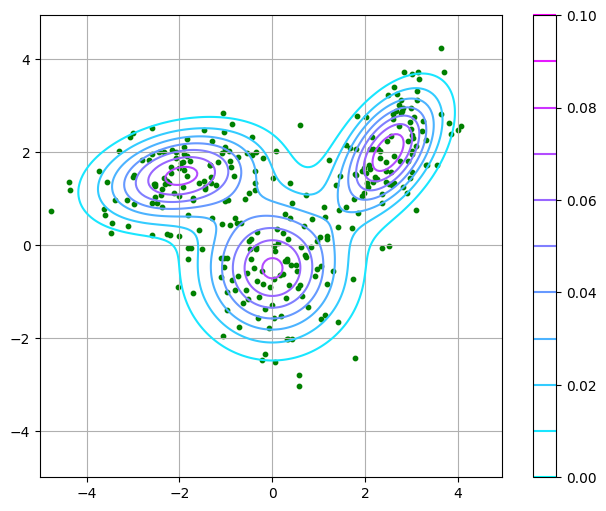

In [13]:
# データ分布とデータ点の可視化
NUM_SAMPLES = 300

x = np.arange(-5, 5, 0.05) # x軸
y = np.arange(-5, 5, 0.05) # y軸

X, Y = np.meshgrid(x, y) # ともに ( 200, 200 )

Z = np.zeros_like(X)
for num in range(len(pi_data_list)):
    # すべての格子点についてまとめてdensityを計算するとメモリ不足になる
    for i in range(X.shape[0]):
        for j in range(Y.shape[1]):
            Z[i][j] += pi_data_list[num] * gaussian_density(
                np.array([X[i][j], Y[i][j]]),
                mu_data_list[num],
                sigma_data_inv_list[num],
                sigma_data_det_list[num]
            )

fig, ax = plt.subplots(figsize=(8.0, 6.0))
cont10 = ax.contour(X, Y, Z, levels=[0.01*i for i in range(11)], cmap='cool')

data_plot = plt.scatter(data_all.T[0, :NUM_SAMPLES], data_all.T[1, :NUM_SAMPLES], s=10, c='g')
ax.set_aspect('equal','box')
plt.colorbar(cont10)
plt.grid(True)
plt.show()

### 2.2 全データ点に対する，混合ガウス分布の対数尤度

混合ガウス分布の対数尤度も，混合ベルヌーイ分布の場合と同様に計算できます．

データ点の数を$N$，混合数を$K$，ガウス分布を$N({\bf x}; {\bf \mu},\Sigma)$とすると，全データ点に対する混合ガウス分布の対数尤度は，

$$
{\rm log}\  p_{\mu,\Sigma}({\rm X})= \sum_{i=1}^N{\rm log}\sum_{k=1}^K\pi_k\ N({\bf x}_i; {\bf \mu}_k, \Sigma_k)
$$

で表されます．

In [14]:
# 全データ点に対する、混合ガウス分布の対数尤度を計算する関数
def log_likelihood(data_all, mu_list, sigma_list, pi_list): # data_all: ( 3000, 2 )
    sigma_inv_list = [np.linalg.inv(sigma) for sigma in sigma_list]
    sigma_det_list = [np.linalg.det(sigma) for sigma in sigma_list]
    log_likely_all = 0
    for data in data_all:
        likely = 0
        for k in range(len(pi_list)):
             likely += pi_list[k] * gaussian_density(data, mu_list[k], sigma_inv_list[k], sigma_det_list[k])
        log_likely_all += np.log(likely)

    return log_likely_all

### 2.3 負担率

負担率も混合ベルヌーイ分布の場合と同様に，

$i$番目のデータ点に対する，$k$番目の潜在変数$z_{ik}$とすると，負担率は，

$$
p_{{\bf \mu},\Sigma,\pi}(z_{ik}=1|{\bf x}_i)
= \frac{\pi_k\ N({\bf x}_i; {\bf \mu}_k, \Sigma_k)}{\sum_{j=1}^K\pi_j\ N({\bf x}_i; {\bf \mu}_j, \Sigma_j)}
\equiv \gamma(z_{ik})
$$

で表されます．

In [15]:
# 負担率を計算する関数
def responsibility(data_all, mu_list, sigma_list, pi_list):
    sigma_inv_list = [np.linalg.inv(sigma) for sigma in sigma_list]
    sigma_det_list = [np.linalg.det(sigma) for sigma in sigma_list]

    gamma_mat = np.zeros((data_all.shape[0], len(pi_list))) # ( 3000, 3 )
    for i in range(gamma_mat.shape[0]):
        for k in range(gamma_mat.shape[1]):
            gamma_mat[i][k] = pi_list[k] * gaussian_density(data_all[i], mu_list[k], sigma_inv_list[k], sigma_det_list[k])
        gamma_mat[i] /= np.sum(gamma_mat[i])
    return gamma_mat

In [16]:
#学習時の可視化を行う関数

def visualization(data_all, mu_list, sigma_inv_list, sigma_det_list):
    x = np.arange(-5, 5, 0.05) # x軸
    y = np.arange(-5, 5, 0.05) # y軸

    X, Y = np.meshgrid(x, y)

    Z = np.zeros_like(X)
    for num in range(len(pi_data_list)):
        for i in range(X.shape[0]):
            for j in range(Y.shape[1]):
                Z[i][j] += pi_list[num] * gaussian_density(np.array([X[i][j], Y[i][j]]), mu_list[num], sigma_inv_list[num], sigma_det_list[num])

    fig, ax = plt.subplots(figsize=(6.0, 4.5))
    data_plot = ax.scatter(data_all.T[0][0:300], data_all.T[1][0:300], s=7, c='g')

    for k in range(len(mu_list)):
        ax.scatter(mu_list[k][0], mu_list[k][1], s=60, c='r', marker='x')

    ax.set_aspect('equal','box')
    cont10 = ax.contour(X, Y, Z, levels=[0.01*i for i in range(11)], cmap='cool')

    plt.colorbar(cont10)
    plt.title("step:{}".format(n_iter))
    plt.grid(True)

    plt.show()

### 2.4 学習

混合ガウス分布に対しても，EMアルゴリズムの基本的な流れは混合ベルヌーイ分布の場合と同じです．しかし，Mステップにおけるパラメータの更新において，共分散行列の更新も行う必要があります．

更新式は以下で表されます（証明等は[こちら](https://qiita.com/kenmatsu4/items/59ea3e5dfa3d4c161efb)などを参照してください）．

$$
\hat{\pi}_k = \frac{N_k}{N}
$$

$$
\hat{\bf \mu}_k = \frac{1}{N_k}\sum_{i=1}^N\gamma(z_{ik}){\bf x}_i
$$

$$
\hat{\Sigma}_k = \frac{1}{N_k}\sum_{i=1}^N\gamma(z_{ik})({\bf x}_i - \hat{\bf \mu}_k)({\bf x}_i - \hat{\bf \mu}_k)^T
$$

$$
ただし，
N_k = \sum_{n=1}^N\gamma(z_{ik})
$$

$\hat{\pi}_k$は全データの負担率の平均値，$\hat{\bf \mu}_k$は各データ点の負担率による重み付き平均値，$\hat{\Sigma}_k$は各データ点の負担率による重み付き共分散に相当します．


Iteration: 0, log_likelihood: -6.190938595851591


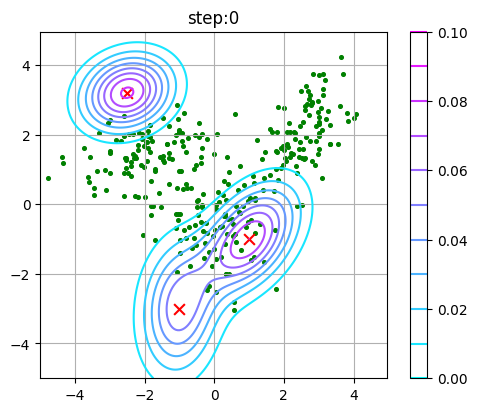

Iteration: 1, log_likelihood: -3.8378742839579756


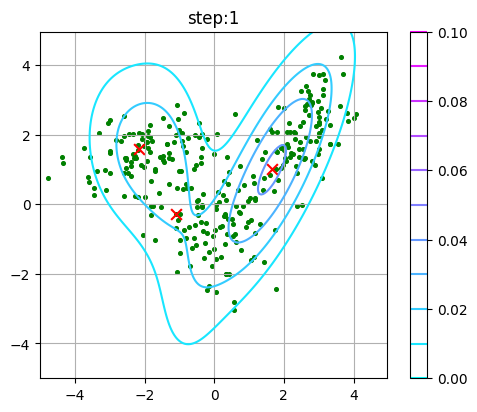

Iteration: 2, log_likelihood: -3.556035312328755


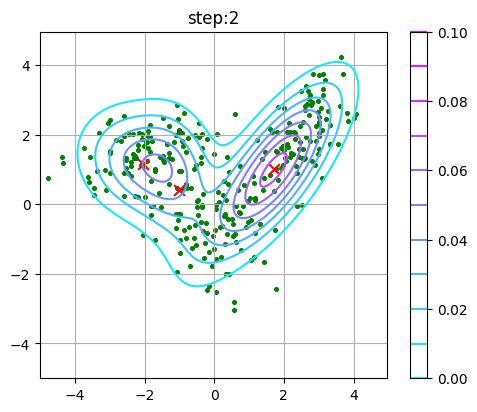

Iteration: 3, log_likelihood: -3.5336393353951667


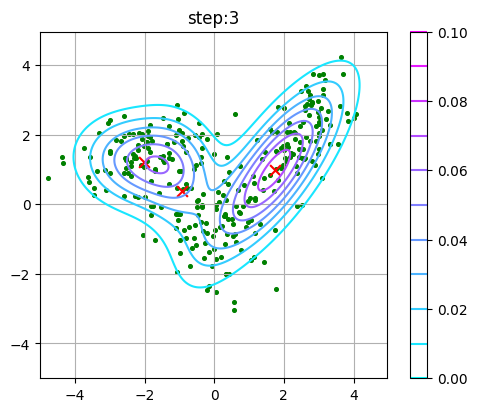

Iteration: 4, log_likelihood: -3.5226496617502012


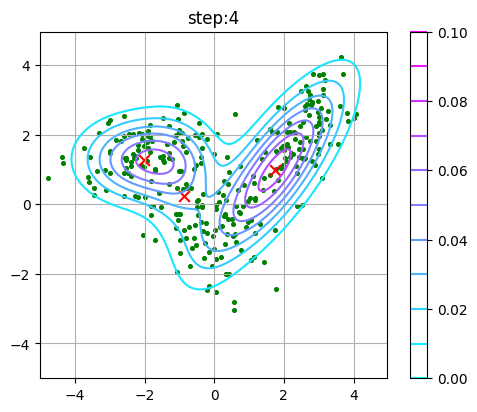

Iteration: 5, log_likelihood: -3.513512067765037


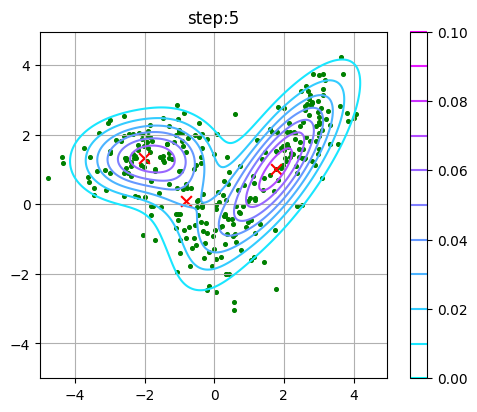

Iteration: 6, log_likelihood: -3.5056831239850488


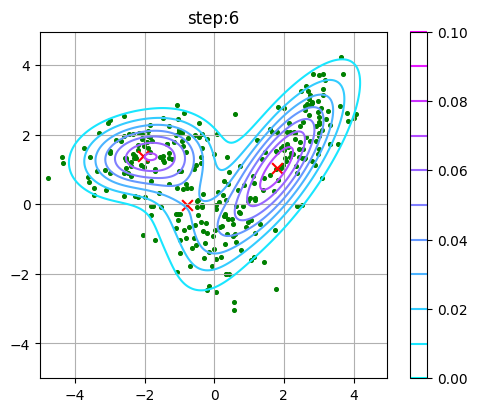

Iteration: 7, log_likelihood: -3.4991679352806555


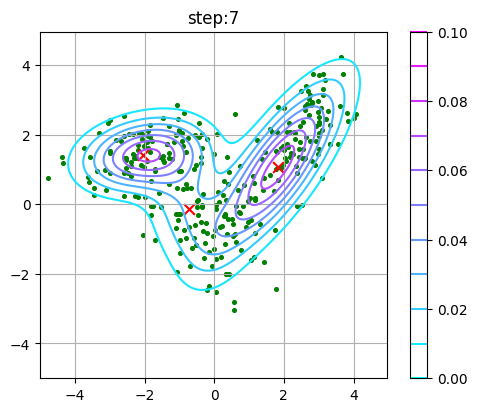

Iteration: 8, log_likelihood: -3.4936783520077728


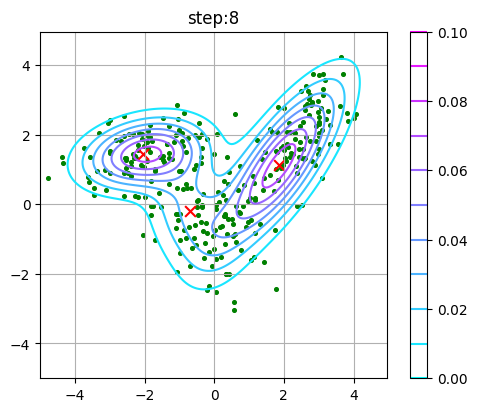

Iteration: 9, log_likelihood: -3.488779480055403


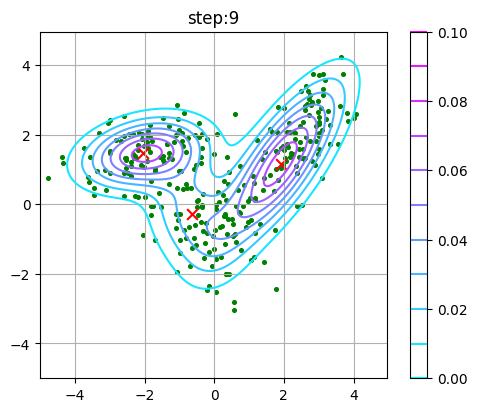

Iteration: 10, log_likelihood: -3.4840755379098223


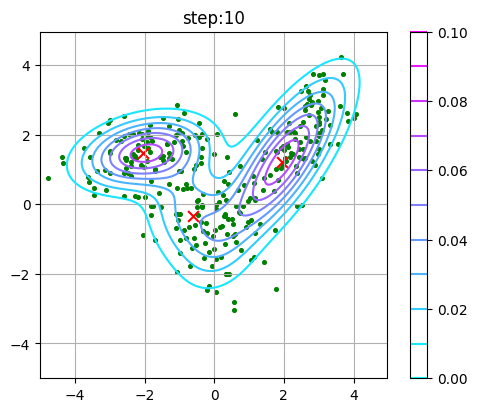

Iteration: 11, log_likelihood: -3.4793067180524764


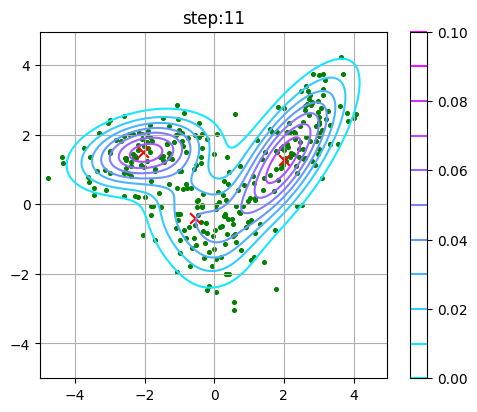

Iteration: 12, log_likelihood: -3.4743278167258627


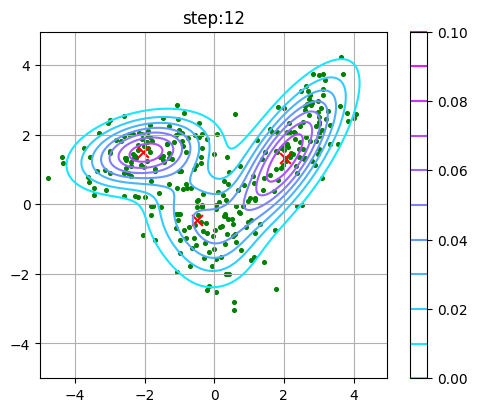

Iteration: 13, log_likelihood: -3.469040275645473


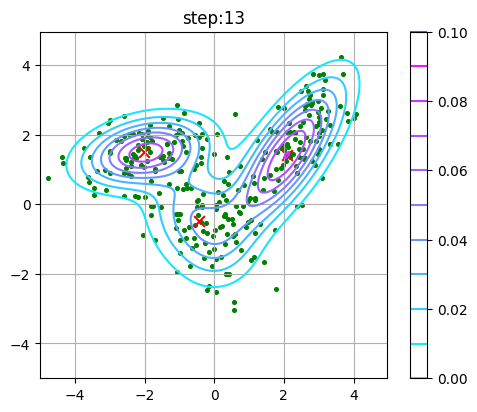

Iteration: 14, log_likelihood: -3.463397393761309


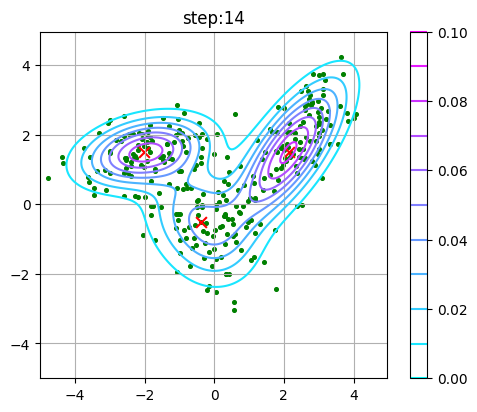

Iteration: 15, log_likelihood: -3.45747316053599


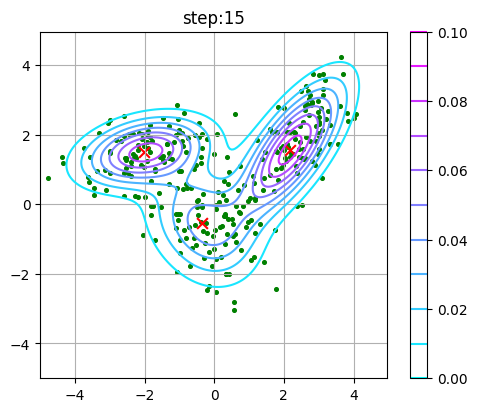

Iteration: 16, log_likelihood: -3.4514783869701295


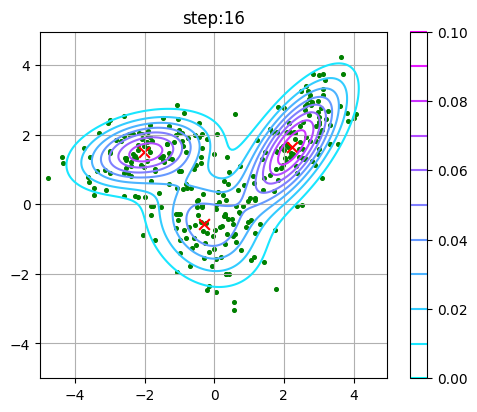

Iteration: 17, log_likelihood: -3.4457094698473334


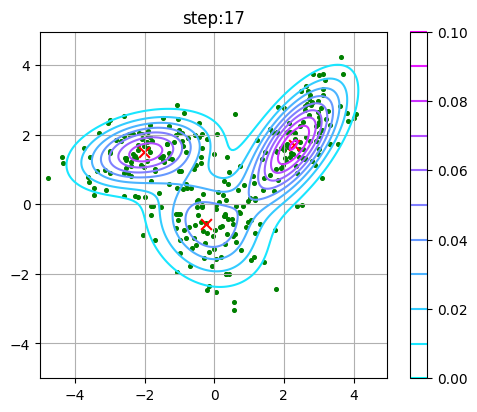

Iteration: 18, log_likelihood: -3.4404884683692702


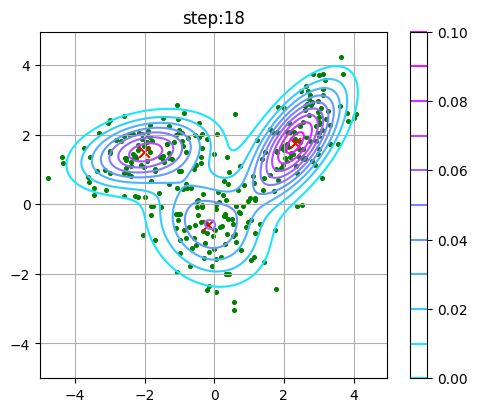

Iteration: 19, log_likelihood: -3.436085738100875


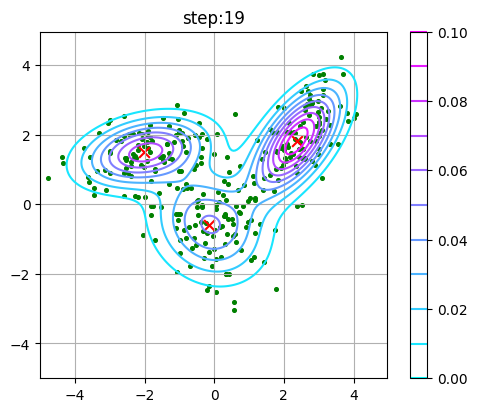

Iteration: 20, log_likelihood: -3.4326379301819365


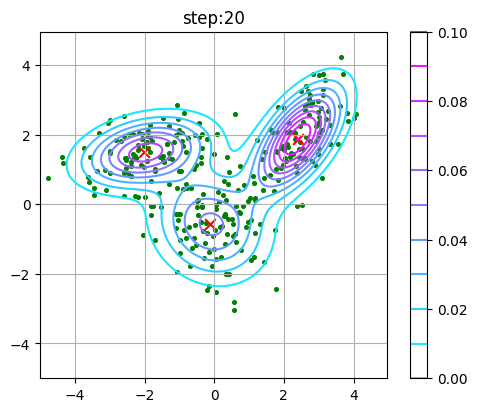

Iteration: 21, log_likelihood: -3.430118320847989


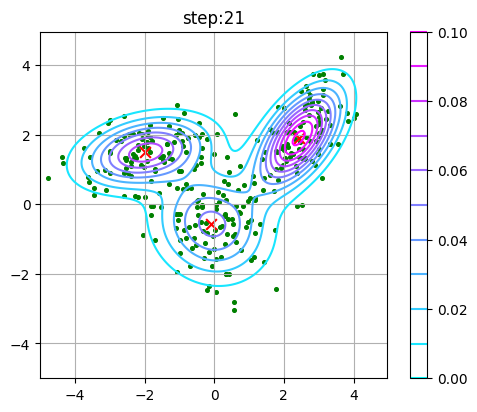

Iteration: 22, log_likelihood: -3.4283791660849467


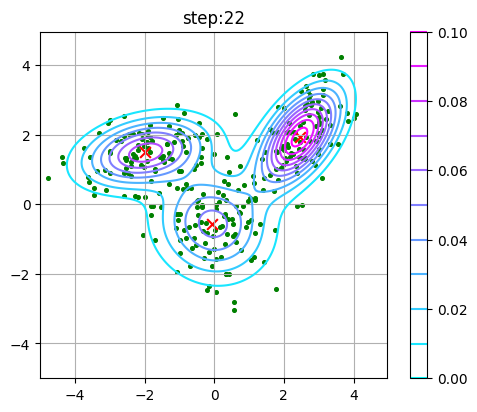

Iteration: 23, log_likelihood: -3.4272275127003224


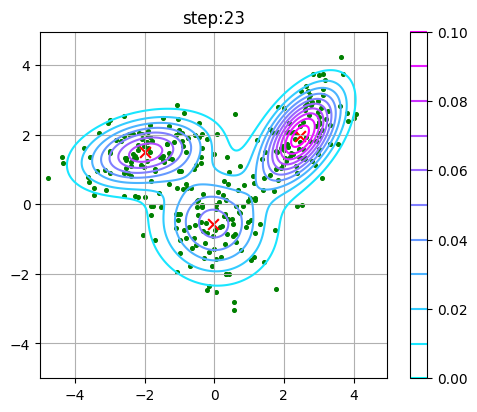

Iteration: 24, log_likelihood: -3.4264850022167006


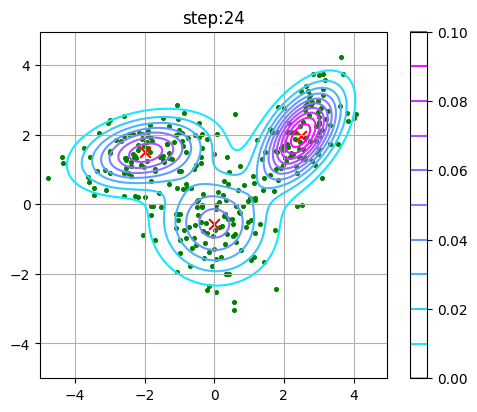

Iteration: 25, log_likelihood: -3.4260135722948344


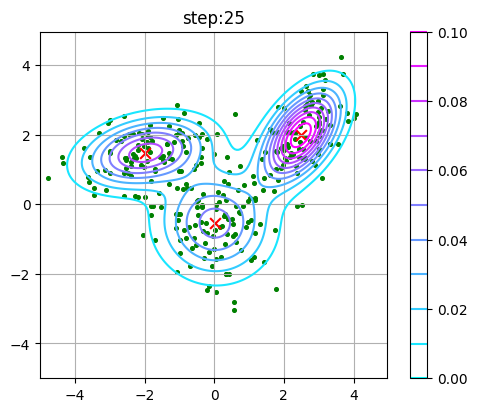

Iteration: 26, log_likelihood: -3.4257165900859707


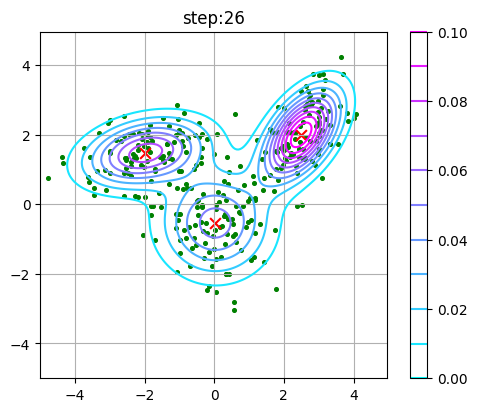

Iteration: 27, log_likelihood: -3.4255301322460143


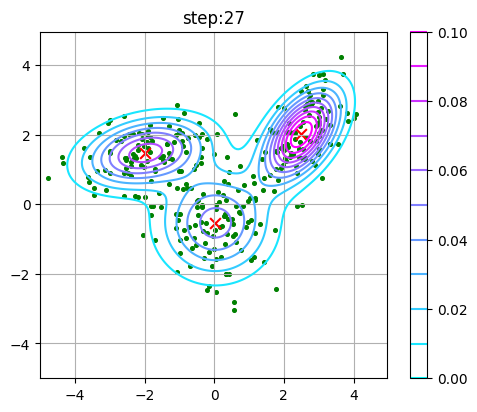

Iteration: 28, log_likelihood: -3.425413175528809


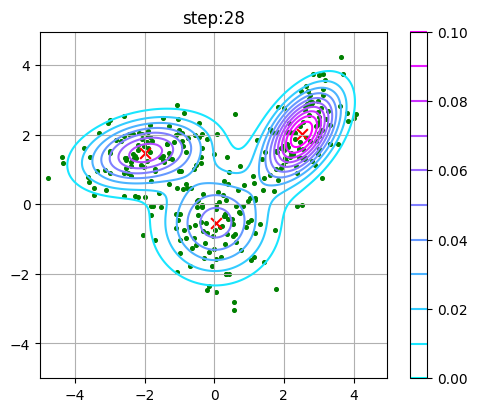

Iteration: 29, log_likelihood: -3.425339792768078


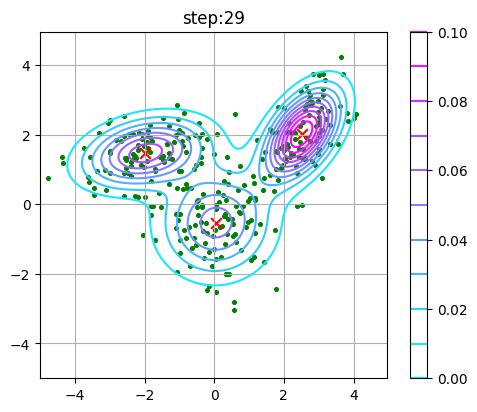

In [18]:
# パラメータ初期化 (適当な値で初期化)
mu0 = np.array([-1, -3])
sigma0 = np.array([[0.5, 0.1], [0.1, 1.5]])

mu1 = np.array([-2.5, 3.2])
sigma1 = np.array([[0.7, 0.1], [0.1, 0.5]])

mu2 = np.array([1, -1])
sigma2 = np.array([[0.8, 0.4], [0.4, 1.0]])

mu_list = [mu0, mu1, mu2]
sigma_list = [sigma0, sigma1, sigma2]
sigma_inv_list = [np.linalg.inv(sigma) for sigma in sigma_list]
sigma_det_list = [np.linalg.det(sigma) for sigma in sigma_list]
pi_list = [0.3, 0.3, 0.4]


n_iter = 0

likely = log_likelihood(data_all, mu_list, sigma_list, pi_list) / NUM_DATA
print('Iteration: {0}, log_likelihood: {1}'.format(n_iter, likely))
visualization(data_all, mu_list, sigma_inv_list, sigma_det_list)


# 下がり幅がth以下になったら収束したと判定する
th = 0.0001

# 学習
while True:
    n_iter += 1

    # Eステップ(負担率計算)
    gamma_mat = responsibility(data_all, mu_list, sigma_list, pi_list)
    n_k = np.sum(gamma_mat, axis=0)

    # Mステップ(パラメータ更新)
    # piの新しい推定量
    pi_list_next = (n_k / n_k.sum()).tolist()

    # gamma_mat: ( 3000, 3 ) data_all: ( 3000, 2 ) n_k: ( 3, )
    mu_list_next = (data_all.T@gamma_mat).T/n_k[:,None]# WRITE ME # ( 3, 2 )

    # muの新しい推定量
    mu_list_next = list(mu_list_next) # [( 2, ), ( 2, ), ( 2, )]

    # Sigmaの新しい推定量
    sigma_list_next = []
    for k in range(len(pi_list)):
        sigma_k = np.zeros_like(sigma_list[k], dtype=float)

        for n in range(data_all.shape[0]):
            sigma_k += gamma_mat[n][k] * np.matmul(
                (data_all[n:n+1] - mu_list[k:k+1]).T,
                (data_all[n:n+1] - mu_list[k:k+1])
            )

        sigma_list_next.append(sigma_k/n_k[k])


    mu_list = copy.deepcopy(mu_list_next)
    sigma_list = copy.deepcopy(sigma_list_next)
    pi_list = copy.deepcopy(pi_list_next)

    sigma_inv_list = [np.linalg.inv(sigma) for sigma in sigma_list]
    sigma_det_list = [np.linalg.det(sigma) for sigma in sigma_list]

    likely_before = likely

    likely = log_likelihood(data_all, mu_list, sigma_list, pi_list) / NUM_DATA

    print('Iteration: {0}, log_likelihood: {1}'.format(n_iter, likely))

    visualization(data_all, mu_list, sigma_inv_list, sigma_det_list)

    delta = likely - likely_before
    if delta < th:
        break

## 3.参考文献
[[1]](https://www.jstor.org/stable/2984875) Dempster, A. P., N. M. Laird, and D. B. Rubin. “Maximum Likelihood from Incomplete Data via the EM Algorithm.” Journal of the Royal Statistical Society. Series B (Methodological) 39, no. 1 (1977): 1–38.